## 데이터셋 준비

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

### No-Aug, 기본 Aug

In [2]:
dataset_dir = "~/work/data_augmentation/data/Images/"
# 경로가 다를 경우 본인 환경에 맞게 수정하세요. 예: dataset_dir = "./data/Images/"

def normalize_and_resize_img():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

def augment():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2)
    ])

def apply_normalize_on_dataset(dataset, is_test=False, batch_size=16, with_aug=False):
    transform = normalize_and_resize_img()
    
    if not is_test and with_aug:
        dataset.dataset.transform = transforms.Compose([
            *augment().transforms,
            *transform.transforms
        ])
    else:
        dataset.dataset.transform = transform

    return DataLoader(dataset, batch_size=batch_size, shuffle=not is_test, num_workers=2, pin_memory=True)

# 데이터셋 로드 및 분리
transform_base = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
full_dataset = ImageFolder(root=dataset_dir, transform=transform_base)

total_size = len(full_dataset)
train_size = int(0.583 * total_size)  # 약 12,000개
test_size = total_size - train_size   # 약 8,580개
ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

ds_info = {"num_classes": len(full_dataset.classes), "class_names": full_dataset.classes}
NUM_CLASSES = ds_info["num_classes"]

# 데이터 로더 생성 (No Aug & Basic Aug)
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)
ds_train_aug = apply_normalize_on_dataset(ds_train, with_aug=True)
ds_test_loader = apply_normalize_on_dataset(ds_test, is_test=True)

### Mixup 적용

In [3]:
# [Mixup 관련 함수]
def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    ratio = torch.rand(1).item()
    label_a_t = torch.as_tensor(label_a, dtype=torch.long)
    label_b_t = torch.as_tensor(label_b, dtype=torch.long)
    
    label_a = F.one_hot(label_a_t, num_classes=num_classes).float()
    label_b = F.one_hot(label_b_t, num_classes=num_classes).float()

    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_image, mixed_label

def mixup(images, labels, batch_size, img_size=224, num_classes=120):
    mixed_imgs, mixed_labels = [], []
    for i in range(batch_size):
        image_a, label_a = images[i], labels[i]
        j = torch.randint(0, batch_size, (1,)).item()
        image_b, label_b = images[j], labels[j]

        mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)
        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    mixed_imgs = torch.stack(mixed_imgs).view(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).view(batch_size, num_classes)
    return mixed_imgs, mixed_labels

### CutMix 적용

In [4]:
# [CutMix 관련 함수]
def get_clip_box(image_a, image_b):
    image_size_x, image_size_y = image_a.shape[2], image_a.shape[1]
    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()
    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)
    return x_min, y_min, x_max, y_max

def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]
    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)
    mixed_img = torch.cat([top, middle, bottom], dim=1)
    return mixed_img

def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes=120):
    image_size_x, image_size_y = 224, 224 # Resize 크기 고정
    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

    label_a_t = torch.as_tensor(label_a, dtype=torch.long)
    label_b_t = torch.as_tensor(label_b, dtype=torch.long)
    
    label_a = F.one_hot(label_a_t, num_classes=num_classes).float()
    label_b = F.one_hot(label_b_t, num_classes=num_classes).float()

    return (1 - ratio) * label_a + ratio * label_b

def cutmix(images, labels, batch_size, img_size=224, num_classes=120):
    mixed_imgs, mixed_labels = [], []
    for i in range(batch_size):
        image_a, label_a = images[i], labels[i]
        j = torch.randint(0, batch_size, (1,)).item()
        image_b, label_b = images[j], labels[j]

        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)
        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes))

    mixed_imgs = torch.stack(mixed_imgs).reshape(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).reshape(batch_size, num_classes)
    return mixed_imgs, mixed_labels

### 준비된 데이터셋 확인하기

1. No Augmentation 데이터셋 확인 (원본 데이터)


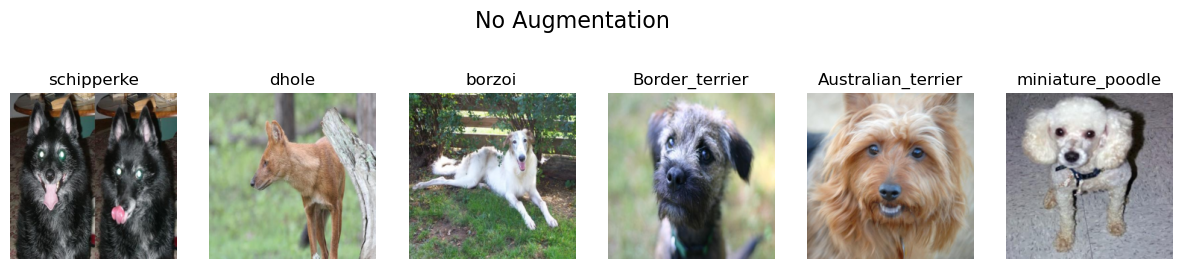

2. Basic Augmentation 데이터셋 확인 (좌우반전, 색상변환 적용)


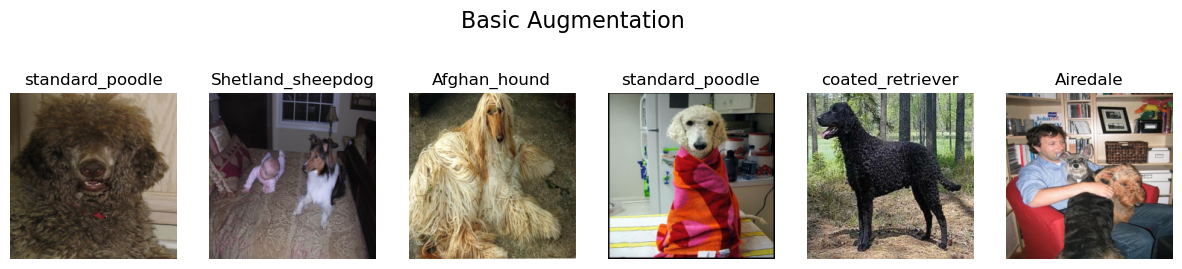

3. Basic + Mixup 적용 데이터셋 확인 (이미지가 투명하게 겹침)


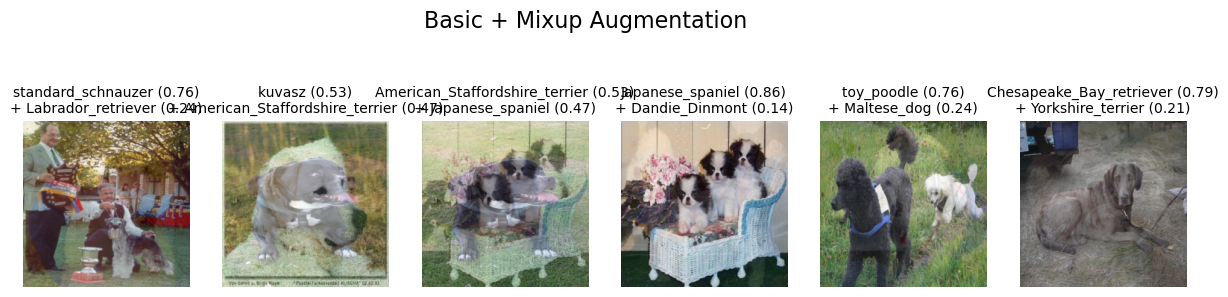

4. Basic + CutMix 적용 데이터셋 확인 (이미지 일부가 잘라져서 붙음)


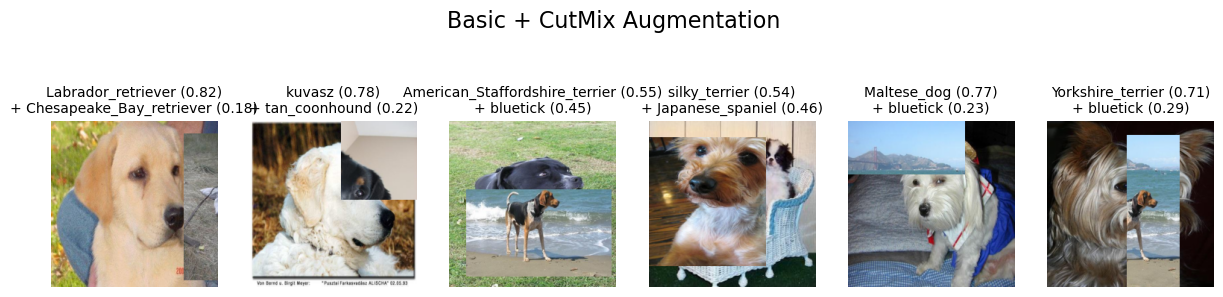

In [5]:
def show_examples(data_loader, class_names, title="Dataset Samples", num_images=6):
    # DataLoader에서 한 배치(batch) 가져오기
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    fig.suptitle(title, fontsize=16, y=1.05)
    
    for i in range(num_images):
        # 1. Tensor를 numpy 배열로 변환하고 차원 순서 변경: (C, H, W) -> (H, W, C)
        image = images[i].permute(1, 2, 0).numpy()
        
        # 2. 정규화 해제 (앞서 mean=0.5, std=0.5로 정규화했으므로 복원)
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1) # 0~1 사이 값으로 클리핑

        # 3. 이미지 출력
        axes[i].imshow(image)
        axes[i].axis('off')
        
        # 클래스 이름 매칭 (폴더명에 포함된 긴 문자열 중 개 이름만 깔끔하게 출력하기 위해 분리)
        class_name = class_names[labels[i].item()]
        class_name_short = class_name.split('-')[-1] if '-' in class_name else class_name
        axes[i].set_title(class_name_short)

    plt.show()

def show_mixed_examples(mixed_images, mixed_labels, class_names, title="Mixed Samples", num_images=6):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3.5))
    fig.suptitle(title, fontsize=16, y=1.05)
    
    for i in range(num_images):
        # 1. Tensor -> Numpy 변환 및 정규화 해제
        image = mixed_images[i].permute(1, 2, 0).cpu().numpy()
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)

        # 2. 이미지 출력
        axes[i].imshow(image)
        axes[i].axis('off')
        
        # 3. 섞인 라벨 확인 (가장 비중이 높은 상위 2개의 클래스 추출)
        top_vals, top_idx = torch.topk(mixed_labels[i], 2)
        idx1, idx2 = top_idx.tolist()
        val1, val2 = top_vals.tolist()
        
        # 클래스 이름 깔끔하게 정리 (폴더명에서 견종만 추출)
        c1 = class_names[idx1].split('-')[-1] if '-' in class_names[idx1] else class_names[idx1]
        c2 = class_names[idx2].split('-')[-1] if '-' in class_names[idx2] else class_names[idx2]
        
        # 비율이 0보다 큰 경우 두 라벨을 모두 표시
        if val2 > 0:
            axes[i].set_title(f"{c1} ({val1:.2f})\n+ {c2} ({val2:.2f})", fontsize=10)
        else:
            axes[i].set_title(f"{c1} ({val1:.2f})", fontsize=10)

    plt.show()

# 실제 데이터 확인하기
print("1. No Augmentation 데이터셋 확인 (원본 데이터)")
show_examples(ds_train_no_aug, ds_info["class_names"], title="No Augmentation")

print("2. Basic Augmentation 데이터셋 확인 (좌우반전, 색상변환 적용)")
show_examples(ds_train_aug, ds_info["class_names"], title="Basic Augmentation")

# 데이터 로더에서 하나의 배치 가져오기
data_iter = iter(ds_train_aug)
images, labels = next(data_iter)

# 배치 크기 확인
current_batch_size = images.size(0)

print("3. Basic + Mixup 적용 데이터셋 확인 (이미지가 투명하게 겹침)")
# Mixup 적용
mixed_imgs, mixed_labels = mixup(images, labels, batch_size=current_batch_size, num_classes=NUM_CLASSES)
show_mixed_examples(mixed_imgs, mixed_labels, ds_info["class_names"], title="Basic + Mixup Augmentation")

print("4. Basic + CutMix 적용 데이터셋 확인 (이미지 일부가 잘라져서 붙음)")
# CutMix 적용
cutmixed_imgs, cutmixed_labels = cutmix(images, labels, batch_size=current_batch_size, num_classes=NUM_CLASSES)
show_mixed_examples(cutmixed_imgs, cutmixed_labels, ds_info["class_names"], title="Basic + CutMix Augmentation")

## 모델 만들기

In [6]:
def create_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    # 이미지넷(1000개 클래스)이 아닌 강아지(120개 클래스)에 맞게 fc층 수정
    model.fc = nn.Linear(model.fc.in_features, num_classes) 
    return model.to(device)

## 모델 훈련

In [7]:
# GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [8]:
EPOCH = 20
criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, test_loader, epochs, aug_type="none"):
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    history = {'train_accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            # 마지막 배치가 지정한 batch_size보다 작을 수 있으므로 동적 크기 할당
            current_batch_size = images.size(0) 
            
            # --- 이곳에서 Mixup / CutMix 배치 단위 적용! ---
            if aug_type == "mixup":
                images, labels = mixup(images, labels, batch_size=current_batch_size, num_classes=NUM_CLASSES)
            elif aug_type == "cutmix":
                images, labels = cutmix(images, labels, batch_size=current_batch_size, num_classes=NUM_CLASSES)
            
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += current_batch_size
            
            # 라벨이 Mixup/CutMix로 섞여 원핫(Soft) 형태일 때와 일반 스칼라일 때 정확도 연산 구분
            if labels.dim() > 1: 
                true_labels = labels.argmax(dim=1)
                correct += predicted.eq(true_labels).sum().item()
            else:
                correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        history['train_accuracy'].append(train_acc)
        
        # Validation 평가 (Test Data는 언제나 Aug 없이 평가)
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"[{aug_type.upper()}] Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    return history


# --- 4가지 실험 진행 ---
print("=== 1. No Augmentation ===")
resnet_no = create_resnet50(NUM_CLASSES)
hist_no = train_model(resnet_no, ds_train_no_aug, ds_test_loader, EPOCH, "none")

print("\n=== 2. Basic Augmentation ===")
resnet_basic = create_resnet50(NUM_CLASSES)
hist_basic = train_model(resnet_basic, ds_train_aug, ds_test_loader, EPOCH, "none")

print("\n=== 3. Basic + Mixup ===")
resnet_mixup = create_resnet50(NUM_CLASSES)
# 데이터로더는 기본 Aug를 쓰되, 함수 내에서 Mixup 적용
hist_mixup = train_model(resnet_mixup, ds_train_aug, ds_test_loader, EPOCH, "mixup")

print("\n=== 4. Basic + CutMix ===")
resnet_cutmix = create_resnet50(NUM_CLASSES)
# 데이터로더는 기본 Aug를 쓰되, 함수 내에서 CutMix 적용
hist_cutmix = train_model(resnet_cutmix, ds_train_aug, ds_test_loader, EPOCH, "cutmix")

=== 1. No Augmentation ===
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]


[NONE] Epoch [1/20], Loss: 0.9261, Train Acc: 53.95%, Val Acc: 78.42%
[NONE] Epoch [2/20], Loss: 0.9132, Train Acc: 80.30%, Val Acc: 80.23%
[NONE] Epoch [3/20], Loss: 0.3672, Train Acc: 88.06%, Val Acc: 80.47%
[NONE] Epoch [4/20], Loss: 0.4484, Train Acc: 93.74%, Val Acc: 81.36%
[NONE] Epoch [5/20], Loss: 0.0676, Train Acc: 96.79%, Val Acc: 81.61%
[NONE] Epoch [6/20], Loss: 0.0771, Train Acc: 98.45%, Val Acc: 83.10%
[NONE] Epoch [7/20], Loss: 0.0656, Train Acc: 99.39%, Val Acc: 81.95%
[NONE] Epoch [8/20], Loss: 0.0519, Train Acc: 99.67%, Val Acc: 83.02%
[NONE] Epoch [9/20], Loss: 0.0065, Train Acc: 99.83%, Val Acc: 82.88%
[NONE] Epoch [10/20], Loss: 0.0138, Train Acc: 99.85%, Val Acc: 82.53%
[NONE] Epoch [11/20], Loss: 0.0256, Train Acc: 99.83%, Val Acc: 82.92%
[NONE] Epoch [12/20], Loss: 0.0190, Train Acc: 99.86%, Val Acc: 82.91%
[NONE] Epoch [13/20], Loss: 0.0087, Train Acc: 99.84%, Val Acc: 82.46%
[NONE] Epoch [14/20], Loss: 0.0139, Train Acc: 99.86%, Val Acc: 82.44%
[NONE] Epoch [1

## 시각화

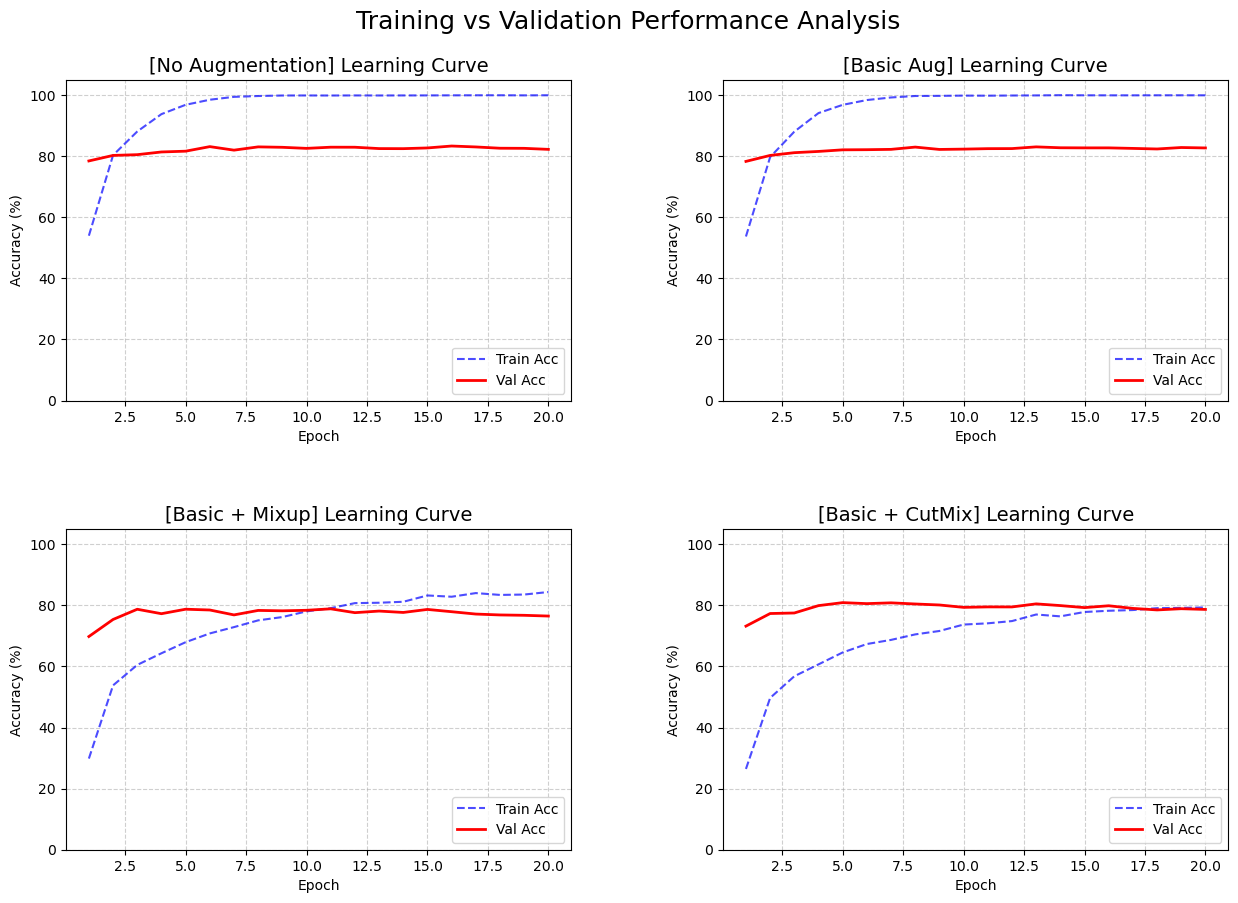

In [9]:
# 전체 그래프 설정 (2x2 그리드로 4가지 기법 표현)
plt.figure(figsize=(15, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 기법 이름과 해당 히스토리 데이터를 리스트로 묶음
experiment_data = [
    ('No Augmentation', hist_no),
    ('Basic Aug', hist_basic),
    ('Basic + Mixup', hist_mixup),
    ('Basic + CutMix', hist_cutmix)
]

epochs_range = range(1, EPOCH + 1)

for i, (name, hist) in enumerate(experiment_data):
    plt.subplot(2, 2, i + 1) # 2행 2열 중 i+1번째 칸
    
    # Train Accuracy vs Validation Accuracy
    plt.plot(epochs_range, hist['train_accuracy'], 'b--', label='Train Acc', alpha=0.7)
    plt.plot(epochs_range, hist['val_accuracy'], 'r-', label='Val Acc', linewidth=2)
    
    plt.title(f'[{name}] Learning Curve', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 105)

plt.suptitle('Training vs Validation Performance Analysis', fontsize=18, y=0.95)
plt.show()

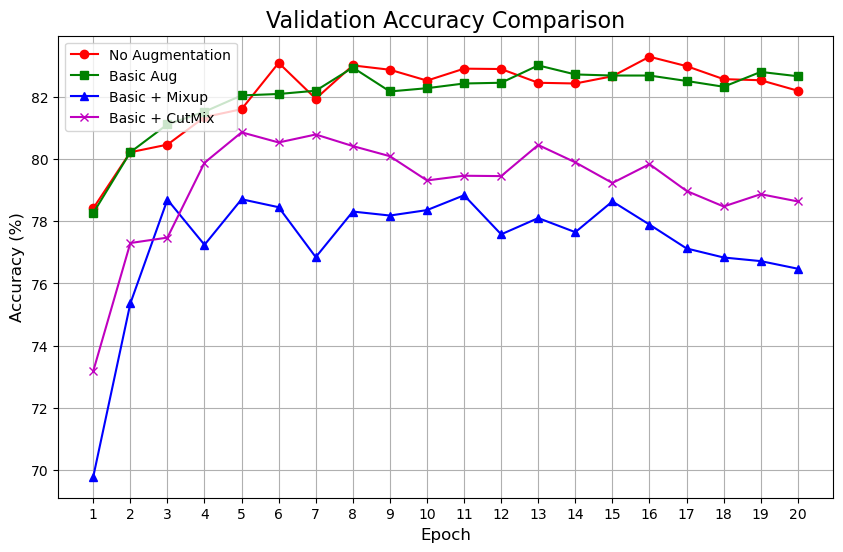

In [10]:
plt.figure(figsize=(10, 6))

epochs_range = range(1, EPOCH + 1)

# Validation Accuracy 그래프 출력
plt.plot(epochs_range, hist_no['val_accuracy'], 'r', label='No Augmentation', marker='o')
plt.plot(epochs_range, hist_basic['val_accuracy'], 'g', label='Basic Aug', marker='s')
plt.plot(epochs_range, hist_mixup['val_accuracy'], 'b', label='Basic + Mixup', marker='^')
plt.plot(epochs_range, hist_cutmix['val_accuracy'], 'm', label='Basic + CutMix', marker='x')

plt.title('Validation Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(epochs_range)

plt.show()

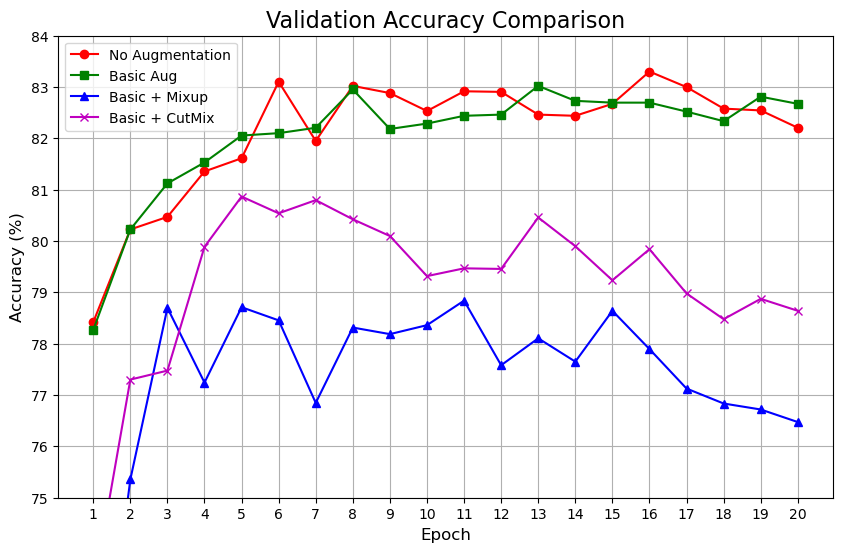

In [15]:
plt.figure(figsize=(10, 6))

epochs_range = range(1, EPOCH + 1)

# Validation Accuracy 그래프 출력
plt.plot(epochs_range, hist_no['val_accuracy'], 'r', label='No Augmentation', marker='o')
plt.plot(epochs_range, hist_basic['val_accuracy'], 'g', label='Basic Aug', marker='s')
plt.plot(epochs_range, hist_mixup['val_accuracy'], 'b', label='Basic + Mixup', marker='^')
plt.plot(epochs_range, hist_cutmix['val_accuracy'], 'm', label='Basic + CutMix', marker='x')

plt.title('Validation Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(epochs_range)
plt.ylim(75, 84) 

plt.show()

## 회고

1. 실험 결과
no_aug, basic_aug, mixup, cutmix 4종류의 데이터를 이용하여 ResNet50 모델 학습을 시키고 시각화 과정을 진행한 결과,  
- no_aug, basic_aug의 경우 학습속도가 매우 빠르게 학습 데이터에 수렴하는 모습을 보여주었다. (각자 7에폭, 8에폭만에 99%를 달성.) 그에 반해, val acc는 80프로대에서 더이상 올라가지 못하는 모습을 보임.
- mixup, cutmix의 경우 수렴 속도가 상대적으로 느리지만 학습데이터, 테스트 데이터 모두 비슷한 값에 수렴하는 모습을 확인할 수 있었다.
   - 더 복잡한 데이터 증강이 이루어져 그만큼 학습의 난이도가 높은 게 원인인 듯 하다

2. 기법별 성능 비교 및 결과 분석
- no_aug 모델은 빠른 학습을 보였지만 train acc에 비해 val acc가 낮은 과적합 현상을 보임
- basic_aug 모델도 no_aug모델과 비슷한 현상을 보였지만 val acc의 변동성이 no_aug에 비해 적었음
- mixup, cutmix 모델은 학습 속도가 눈에 띄게 느렸지만 train, val acc 사이의 간격이 좁게 유지되는 모습을 보여줌
  - 고로, mixup, cutmix 모델의 경우 에폭 수를 더 늘려줬다면 결국 더 안정적인 학습과정과 높은 정확도로 수렴하는 모습을 보여줬을 것이라 기대됨.
- 표로 정리
|Augmentation 기법|최종 Train Acc|최고 Val Acc (Best)|특이 사항|
|---|---|---|---|
|No Augmentation|99.92%|83.30%|가장 빠른 수렴, 전형적인 과적합 패턴|
|Basic Augmentation|99.90%|83.02%|No Aug와 유사하지만 보다 안정적|
|Basic + Mixup|84.34%|78.84%|학습 속도가 가장 느림|
|Basic + CutMix|79.28%|80.87%|Mixup과 비슷하지만 보다 안정적|

3. 태스크 최적 기법 찾아내기 (with 문제점)
- 이번 학습(20 epochs) 기준으로는 no_aug, basic_aug의 경우 과적합을 보여줬고 mixup의 경우 가장 낮은 정확도를 보여주었기에 **cutmix**가 가장 최적의 기법이라고 판단되었다.
- 픽셀을 섞어 사람이 보기에도 복잡한 mixup보다는 영역을 잘라 붙이는 cutmix가 모델이 일반화 특징을 파악하는 데 더 유리했을 것이라 생각이 들었다.
- 문제점
   - 에포크 부족: cutmix, mixup처럼 더 강도높은 augmentation 기법일수록 수렴에 필요한 시간이 더 많이 필요하다 (위 실험의 20에폭은 cutmix와 mixup의 성능을 온전히 평가하기에 부족한 수치였음)
   - 데이터 복잡도: 에포크 부족 문제와 마찬가지로, mixup, cutmix 모델의 loss가 1.0 이하로 떨어지지 못하는 결과를 확인.

4. 정리
학습 정확도가 빠르게, 높게 수렴한다고 해서 좋은 것이 아니라는 사실. 과적합 현상을 다시 한번 제대로 확인할 수 있었다. 또한, mixup, cutmix라는 강도 높은 augmentation기법을 학습할 때에는 훨씬 많은 에폭으로 학습시켜야 한다는 점을 알 수 있었다. augmenation기법을 왜 쓰는지, 딥러닝에 왜 많은 데이터가 필요한지도 느낄 수 있는 실험이었던 것 같다.
향후 더 많은 에폭으로 학습할 시간이 확보된다면, mixup/cutmix와 더불어 더 복잡한 aug기법을 적용한 모델들이 어떻게 최종적으로 수렴하는지와 no_aug, basic_aug 모델을 역전하는 골드 크로스 지점을 시각화해보고 싶다.